**Задача 1**

Примените алгоритм Metropolis для генерации выборки из распределения с плотностью p(x) = 0.3N(-4, 2) + 0.7N(3, 6), где N(a, b) - плотность нормального распределения со средним a и дисперсией b. Для наглядности, ниже приведен график плотности смеси. Покажите, что гистограмма, построенная по выборке, приближает заданную плотность смеси.

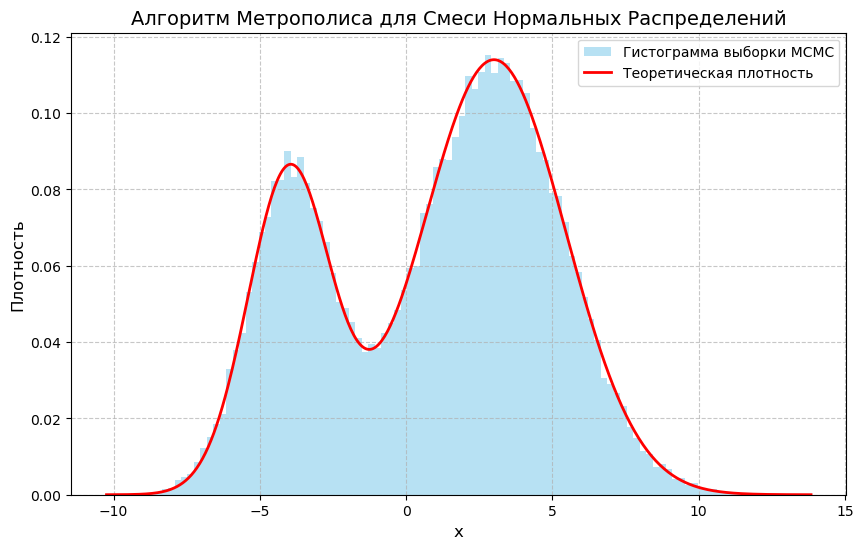

In [6]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def target_density(x):
        p1 = 0.3 * norm.pdf(x, -4, np.sqrt(2))
        p2 = 0.7 * norm.pdf(x, 3, np.sqrt(6))
        return p1 + p2

def metropolis_sampler(n_samples = 100000, burn_in = 1000, proposal_sigma_sq = 10, initial_x = 0.0):
    x_current = initial_x
    samples = []
    proposal_sigma = np.sqrt(proposal_sigma_sq)
    for t in range(n_samples):
        x_star = np.random.normal(loc=x_current, scale=proposal_sigma)
        p_star = target_density(x_star)
        p_current = target_density(x_current)
        
        if p_current == 0:
             alpha = 1.0
            
        else:
             alpha = min(1.0, p_star / p_current)
            
        if np.random.rand() <= alpha:
            x_current = x_star
            
        if t >= burn_in:
            samples.append(x_current)

    return np.array(samples)

final_samples = metropolis_sampler(100000, 1000, 10)

plt.figure(figsize=(10, 6))

plt.hist(final_samples, bins=100, density=True, alpha=0.6, color='skyblue', label='Гистограмма выборки MCMC')

x_vals = np.linspace(np.min(final_samples) - 1, np.max(final_samples) + 1, 500)
p_vals = target_density(x_vals)
plt.plot(x_vals, p_vals, 'r-', linewidth=2, label='Теоретическая плотность')

plt.title('Алгоритм Метрополиса для Смеси Нормальных Распределений', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Задача 2**

Ожидаемое значение: 1.1428571428571428
Оценка: 1.142949494949495
Оценка для 10x10: 23.653030303030302


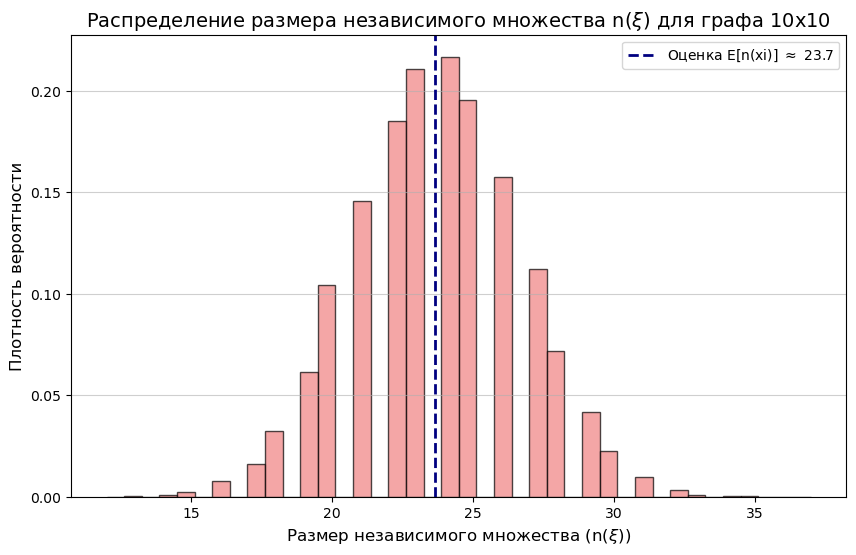

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def get_neighbors(v, n_grid):
        r, c = divmod(v, n_grid)
        neighbors = []
        # Соседи: вверх, вниз, влево, вправо
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < n_grid and 0 <= nc < n_grid:
                neighbors.append(nr * n_grid + nc)
        return neighbors
    
def metropolis_independent_set(n_grid, n_steps=1000000 ,burn_in=10000, collection_period=10):
    n_vertices = n_grid * n_grid
    
    neighbors_list = [get_neighbors(v, n_grid) for v in range(n_vertices)]

    config = np.zeros(n_vertices, dtype=int)
    samples = []

    for t in range(n_steps):
        v = np.random.randint(n_vertices)
        new_val = 1 - config[v]
        
        can_change = False
        if new_val == 0:
            can_change = True
        else:
            # Проверяем, есть ли закрашенные соседи
            is_neighbor_occupied = any(config[u] == 1 for u in neighbors_list[v])
            if not is_neighbor_occupied:
                can_change = True

        #Принятие с вероятностью 0.5
        if can_change and np.random.rand() < 0.5:
            config[v] = new_val
        
        if t >= burn_in and t % collection_period == 0:
            n_xi = np.sum(config)
            samples.append(n_xi)

    mcmc_samples = np.array(samples)
    E_n_xi_estimate = np.mean(mcmc_samples)
    
    return E_n_xi_estimate, mcmc_samples

E2, samples2 = metropolis_independent_set(2)
print(f"Ожидаемое значение: {8/7}")
print(f"Оценка: {E2}")
E10, samples10 = metropolis_independent_set(10)

print(f"Оценка для 10x10: {E10}")
plt.figure(figsize=(10, 6))

plt.hist(samples10, bins=40, density=True, color='lightcoral', edgecolor='black', alpha=0.7)

plt.axvline(E10, color='navy', linestyle='dashed', linewidth=2, 
            label=f'Оценка E[n(xi)] $\\approx$ {E10:.1f}')

plt.title(f'Распределение размера независимого множества n($\\xi$) для графа {10}x{10}', fontsize=14)
plt.xlabel('Размер независимого множества (n($\\xi$))', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.6)
plt.show()